# Analyse exploratoire

In [1]:
#Imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Vérification de la qualité des données

In [2]:
train = pd.read_csv("../data/raw/application_train.csv")
test  = pd.read_csv("../data/raw/application_test.csv")


print("Train shape :", train.shape)
print("Test shape  :", test.shape)


Train shape : (307511, 122)
Test shape  : (48744, 121)


In [3]:

train = pd.read_csv("../data/raw/application_train.csv")

bureau = pd.read_csv("../data/raw/bureau.csv")
prev   = pd.read_csv("../data/raw/previous_application.csv")
inst   = pd.read_csv("../data/raw/installments_payments.csv")
pos    = pd.read_csv("../data/raw/POS_CASH_balance.csv")
cc     = pd.read_csv("../data/raw/credit_card_balance.csv")
bb     = pd.read_csv("../data/raw/bureau_balance.csv")

print("train", train.shape)
print("bureau", bureau.shape, "| clients:", bureau["SK_ID_CURR"].nunique())
print("prev", prev.shape, "| clients:", prev["SK_ID_CURR"].nunique())
print("inst", inst.shape, "| clients:", inst["SK_ID_CURR"].nunique())
print("pos", pos.shape, "| clients:", pos["SK_ID_CURR"].nunique())
print("cc", cc.shape, "| clients:", cc["SK_ID_CURR"].nunique())
print("bb", bb.shape, "| bureaux:", bb["SK_ID_BUREAU"].nunique())


train (307511, 122)
bureau (1716428, 17) | clients: 305811
prev (1670214, 37) | clients: 338857
inst (13605401, 8) | clients: 339587
pos (10001358, 8) | clients: 337252
cc (3840312, 23) | clients: 103558
bb (27299925, 3) | bureaux: 817395


In [4]:
#Vérification des types de varibales
train.dtypes.value_counts()
train.info()

train.select_dtypes(include="object").columns

for col in train.select_dtypes(include="object").columns:
    print(col, train[col].nunique())

int_cols = train.select_dtypes(include="int64").columns
int_cols[:20]

train["SK_ID_CURR"].nunique()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
NAME_CONTRACT_TYPE 2
CODE_GENDER 3
FLAG_OWN_CAR 2
FLAG_OWN_REALTY 2
NAME_TYPE_SUITE 7
NAME_INCOME_TYPE 8
NAME_EDUCATION_TYPE 5
NAME_FAMILY_STATUS 6
NAME_HOUSING_TYPE 6
OCCUPATION_TYPE 18
WEEKDAY_APPR_PROCESS_START 7
ORGANIZATION_TYPE 58
FONDKAPREMONT_MODE 4
HOUSETYPE_MODE 3
WALLSMATERIAL_MODE 7
EMERGENCYSTATE_MODE 2


307511

In [5]:
#vérification des doublons
train.duplicated().sum()
train["SK_ID_CURR"].duplicated().sum()

np.int64(0)

In [6]:
#cohérence des identifiants 
#Vérification du nombre total d'identifiants uniques
train["SK_ID_CURR"].nunique()

#Vérification qu'il n'y a pas d'identifiants manquants
train["SK_ID_CURR"].isna().sum()



np.int64(0)

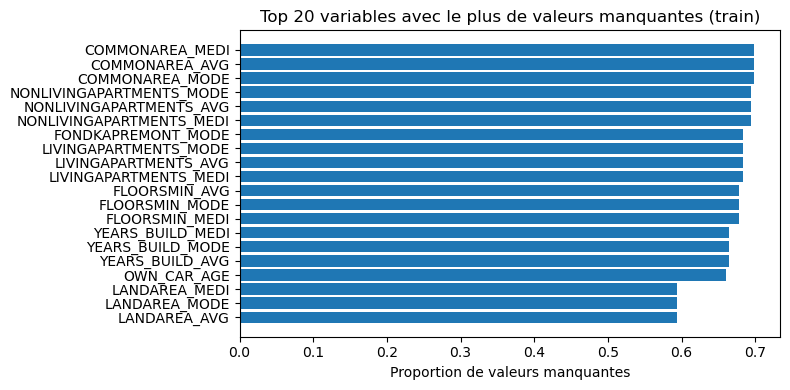

Nb colonnes >70% missing: 0
Nb colonnes 40-70%: 49
Nb colonnes <=40%: 73


In [7]:
# Valeurs manquantes
missing = train.isna().mean().sort_values(ascending=False)
top = missing.head(20)

plt.figure(figsize=(8,4))
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top 20 variables avec le plus de valeurs manquantes (train)")
plt.xlabel("Proportion de valeurs manquantes")
plt.tight_layout()
plt.show()

print("Nb colonnes >70% missing:", (missing > 0.7).sum())
print("Nb colonnes 40-70%:", ((missing > 0.4) & (missing <= 0.7)).sum())
print("Nb colonnes <=40%:", (missing <= 0.4).sum())


In [8]:
#Valeurs abérantes 

# Vérification des âges (variable DAYS_BIRTH négative)
age = -train["DAYS_BIRTH"] / 365
age.describe()

# Vérification des revenus
train["AMT_INCOME_TOTAL"].describe()

# Vérification des montants de crédit
train["AMT_CREDIT"].describe()

# Vérification des annuités
train["AMT_ANNUITY"].describe()



count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

In [9]:
# Vérification des valeurs impossibles pour l'âge
(age < 18).sum()
(age > 100).sum()

# Vérification des revenus nuls ou négatifs
(train["AMT_INCOME_TOTAL"] <= 0).sum()


np.int64(0)

In [10]:
# Séparation variable cible / variables explicatives
target = train["TARGET"]
features = train.drop(columns=["TARGET"])

# Vérification distribution de la cible
print("Distribution TARGET :")
print(target.value_counts())
print("\nProportion classe 1 :", target.mean())


Distribution TARGET :
TARGET
0    282686
1     24825
Name: count, dtype: int64

Proportion classe 1 : 0.08072881945686496


## Analyse des variables 
Dans cette partie nous allons analyser la variables cibles ainsi que les variables explicatives du projet. 

### Analyse de la variable cible

In [11]:
train["TARGET"].value_counts()
train["TARGET"].value_counts(normalize=True)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

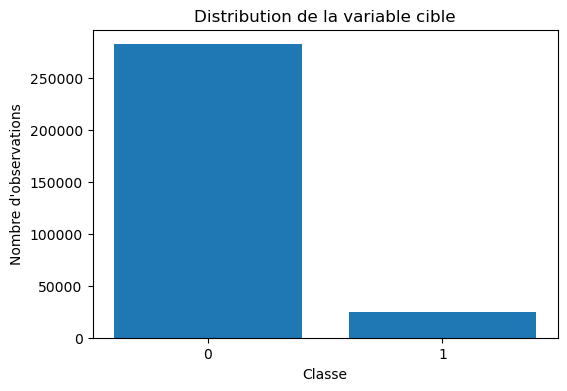

In [12]:
target_counts = train["TARGET"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Distribution de la variable cible")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()


L'analyse de la cible nous permet de mettre en avant les éléments suivant : 
- La classe majoritaire (clients solvables) représente ~92 % des observations.
- La classe minoritaire (défaut de paiement) représente ~8 %.
- Le dataset est fortement déséquilibré.

Ainsi, la classe 1 (défaut) représente environ 8 % des observations, ce qui indique un fort déséquilibre de classes. Ce déséquilibre devra être pris en compte lors de la modélisation (pondération des classes, métriques adaptées comme le recall ou l’AUC, etc.).

### Analyse des variables explicatives

#### Variables numériques importantes

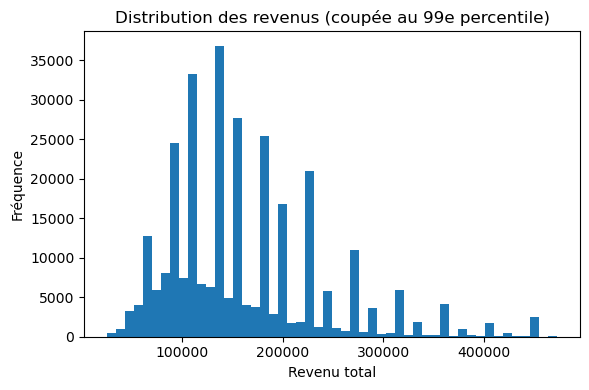

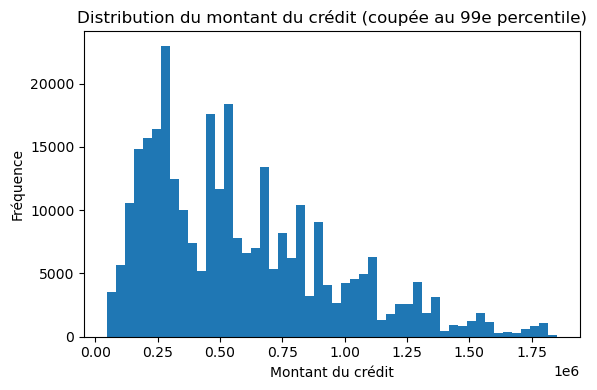

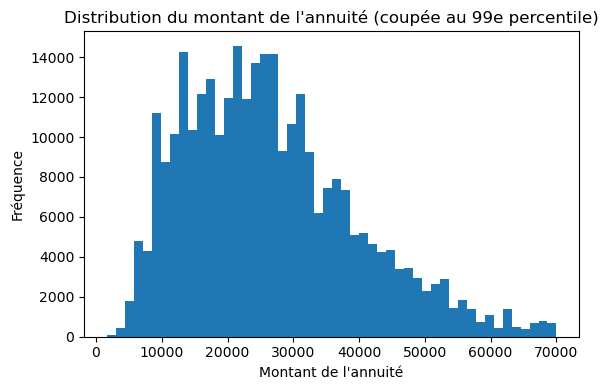

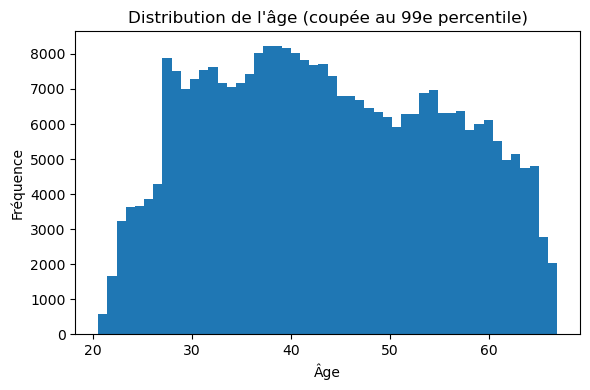

In [13]:
def hist_clip99(series, title, xlabel, bins=50):
    s = series.dropna()
    p99 = np.percentile(s, 99)
    s = s[s <= p99]
    plt.figure(figsize=(6,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()

hist_clip99(train["AMT_INCOME_TOTAL"],
            "Distribution des revenus (coupée au 99e percentile)",
            "Revenu total")

hist_clip99(train["AMT_CREDIT"],
            "Distribution du montant du crédit (coupée au 99e percentile)",
            "Montant du crédit")

hist_clip99(train["AMT_ANNUITY"],
            "Distribution du montant de l'annuité (coupée au 99e percentile)",
            "Montant de l'annuité")

age = (-train["DAYS_BIRTH"] / 365.25)
hist_clip99(age,
            "Distribution de l'âge (coupée au 99e percentile)",
            "Âge")


### Variables catégorielles importantes

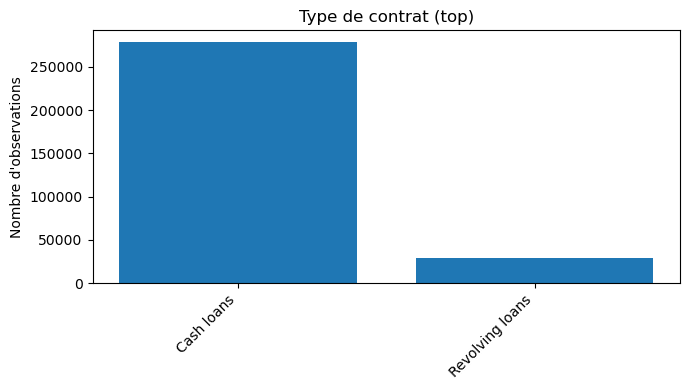

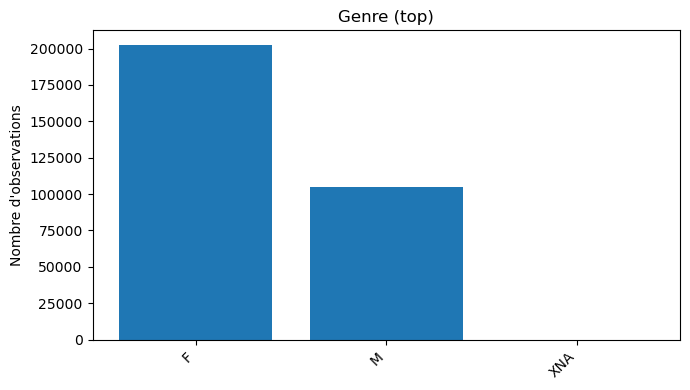

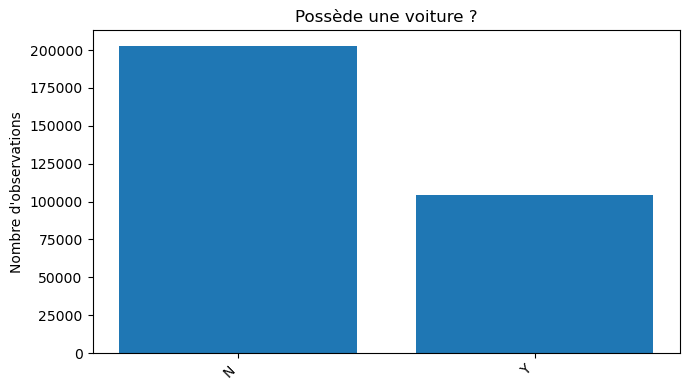

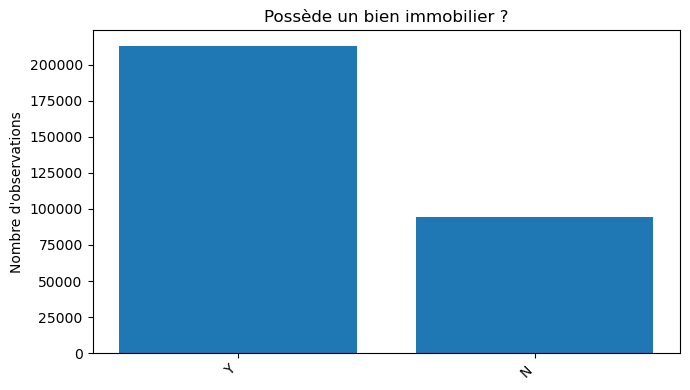

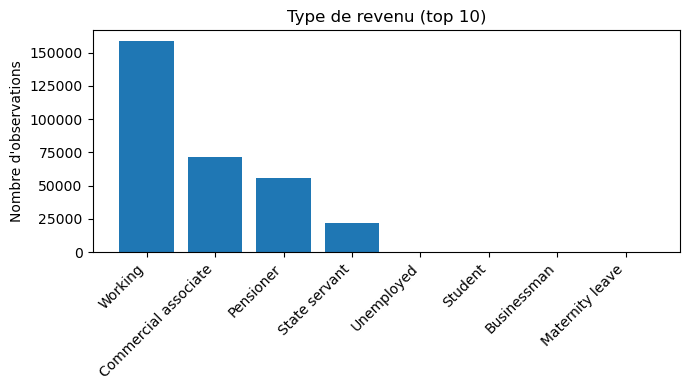

In [14]:
def bar_top(series, title, topn=10):
    vc = series.astype("object").value_counts().head(topn)
    plt.figure(figsize=(7,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.ylabel("Nombre d'observations")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

bar_top(train["NAME_CONTRACT_TYPE"], "Type de contrat (top)")
bar_top(train["CODE_GENDER"], "Genre (top)")
bar_top(train["FLAG_OWN_CAR"], "Possède une voiture ?")
bar_top(train["FLAG_OWN_REALTY"], "Possède un bien immobilier ?")
bar_top(train["NAME_INCOME_TYPE"], "Type de revenu (top 10)", topn=10)


#### Corrélations entre cible et variables

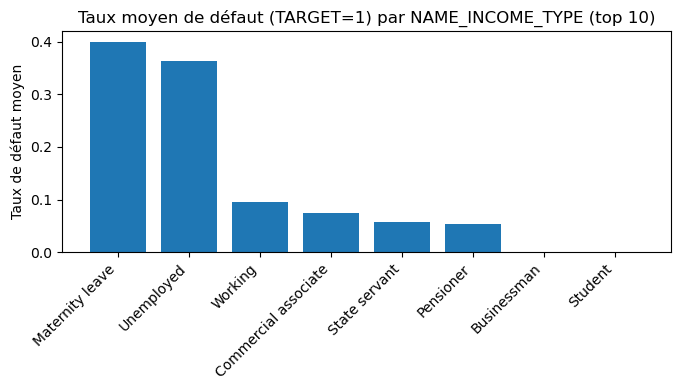

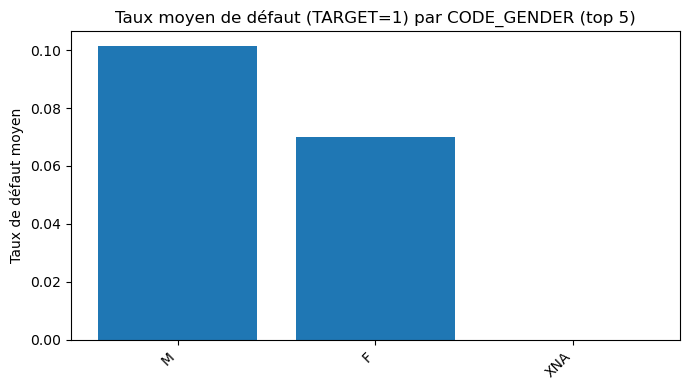

In [15]:
def default_rate_by_cat(df, col, topn=10):
    tmp = df[[col, "TARGET"]].dropna()
    top = tmp[col].value_counts().head(topn).index
    tmp = tmp[tmp[col].isin(top)]
    rate = tmp.groupby(col)["TARGET"].mean().sort_values(ascending=False)

    plt.figure(figsize=(7,4))
    plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Taux moyen de défaut (TARGET=1) par {col} (top {topn})")
    plt.ylabel("Taux de défaut moyen")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

default_rate_by_cat(train, "NAME_INCOME_TYPE", topn=10)
default_rate_by_cat(train, "CODE_GENDER", topn=5)


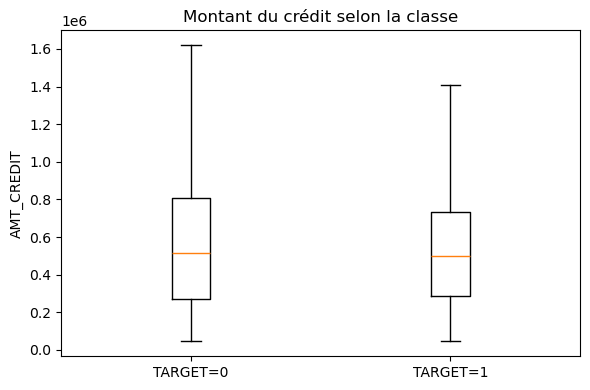

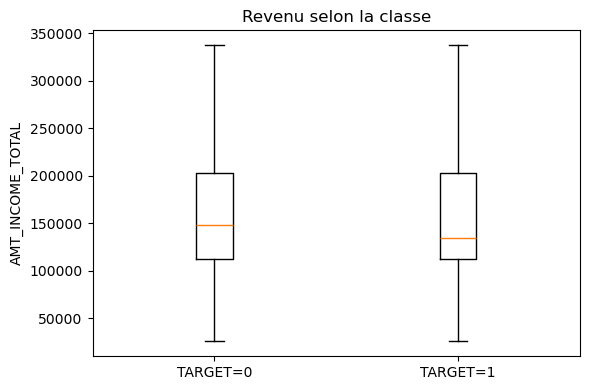

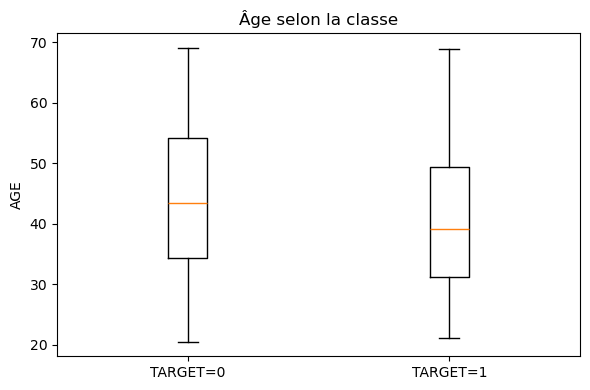

In [16]:
def box_by_target(df, col, title):
    tmp = df[[col, "TARGET"]].dropna()
    data0 = tmp[tmp["TARGET"]==0][col]
    data1 = tmp[tmp["TARGET"]==1][col]
    plt.figure(figsize=(6,4))
    plt.boxplot([data0, data1], tick_labels=["TARGET=0", "TARGET=1"], showfliers=False)
    plt.title(title)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

box_by_target(train, "AMT_CREDIT", "Montant du crédit selon la classe")
box_by_target(train, "AMT_INCOME_TOTAL", "Revenu selon la classe")
box_by_target(train.assign(AGE=(-train["DAYS_BIRTH"]/365.25)), "AGE", "Âge selon la classe")


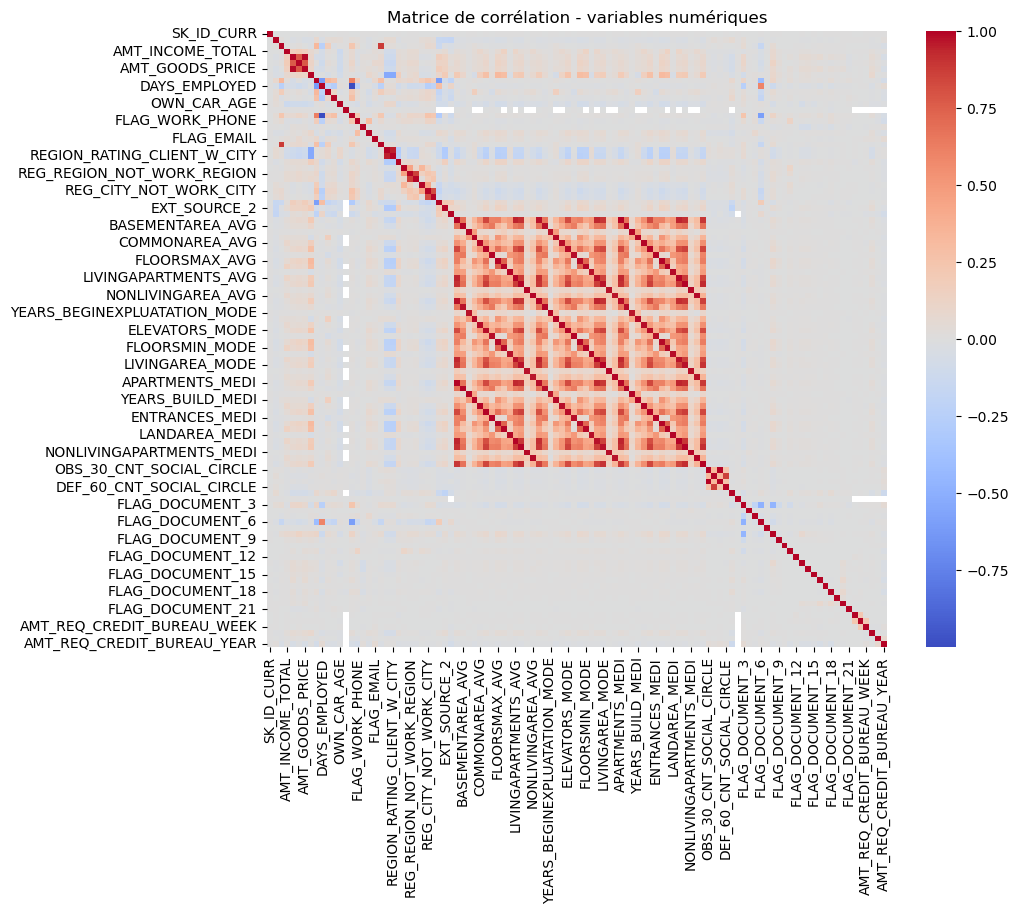

In [17]:

num_cols = train.select_dtypes(include=["int64", "float64"]).columns
corr = train[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - variables numériques")
plt.show()


#### Synthèse des variables 

Les différentes visualisations nous permettent de mettre en avant les éléments suivant : 
- La variable cible est fortement déséquilibrée (~8 % de défaut), ce qui impose l’utilisation de métriques adaptées et d’un score métier pondéré.
- Aucune variable ne dépasse 70 % de valeurs manquantes, mais 49 variables présentent entre 40 % et 70 % de données manquantes : une stratégie d’imputation sera nécessaire.
- Les distributions numériques présentent des asymétries et des valeurs extrêmes, justifiant l’usage éventuel de transformations robustes.
- Certaines variables catégorielles montrent des différences marquées de taux de défaut selon les modalités.
- Les premières analyses suggèrent que certaines variables socio-économiques (revenu, type d’emploi, âge) pourraient contribuer significativement au pouvoir prédictif du modèle.

### Jointures et agrégations des tables secondaires

Les tables secondaires (previous_application, bureau, installments_payments, POS_CASH_balance, credit_card_balance) contiennent des informations transactionnelles au niveau des crédits passés ou des paiements.

Afin de pouvoir entraîner un modèle au niveau client (1 ligne = 1 client), ces tables sont agrégées par SK_ID_CURR.

Chaque agrégation vise à résumer l’historique financier du client à travers :
- le nombre de crédits passés,
- les montants moyens et cumulés,
- les retards de paiement,
- les comportements de sous-paiement.

Les agrégations sont ensuite fusionnées avec la table principale via des jointures left, en conservant l’intégralité des clients.

In [18]:
train.duplicated("SK_ID_CURR").sum()


np.int64(0)

In [19]:
prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_COUNT=("SK_ID_PREV", "count"),
    PREV_AMT_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
    PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
    PREV_AMT_CREDIT_SUM=("AMT_CREDIT", "sum"),
)
prev_agg = prev_agg.reset_index()

train2 = train.merge(prev_agg, on="SK_ID_CURR", how="left")

print("train2", train2.shape)
print("dup clients:", train2.duplicated("SK_ID_CURR").sum())


train2 (307511, 126)
dup clients: 0


In [20]:
bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_MIN=("MONTHS_BALANCE", "min"),
    BB_MONTHS_MAX=("MONTHS_BALANCE", "max"),
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
)

bb_agg = bb_agg.reset_index()

print(bb_agg.shape)


(817395, 4)


In [21]:
bureau2 = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")

print(bureau2.shape)


(1716428, 20)


In [22]:
bureau_agg = bureau2.groupby("SK_ID_CURR").agg(
    BUREAU_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_CREDIT_SUM_MEAN=("AMT_CREDIT_SUM", "mean"),
    BUREAU_CREDIT_SUM_DEBT_MEAN=("AMT_CREDIT_SUM_DEBT", "mean"),
    BUREAU_BB_MONTHS_COUNT_MEAN=("BB_MONTHS_COUNT", "mean"),
)

bureau_agg = bureau_agg.reset_index()

print(bureau_agg.shape)


(305811, 5)


In [23]:
train3 = train2.merge(bureau_agg, on="SK_ID_CURR", how="left")

print("train3 shape:", train3.shape)
print("dup clients:", train3.duplicated("SK_ID_CURR").sum())


train3 shape: (307511, 130)
dup clients: 0


In [24]:
inst2 = inst.copy()

# jours de retard (positif = en retard)
inst2["DAYS_LATE"] = inst2["DAYS_ENTRY_PAYMENT"] - inst2["DAYS_INSTALMENT"]
inst2["LATE_FLAG"] = (inst2["DAYS_LATE"] > 0).astype(int)

# écart paiement (positif = pas assez payé)
inst2["AMT_DIFF"] = inst2["AMT_INSTALMENT"] - inst2["AMT_PAYMENT"]
inst2["UNDERPAY_FLAG"] = (inst2["AMT_DIFF"] > 0).astype(int)

inst_agg = inst2.groupby("SK_ID_CURR").agg(
    INST_COUNT=("SK_ID_CURR", "count"),
    INST_DAYS_LATE_MEAN=("DAYS_LATE", "mean"),
    INST_DAYS_LATE_MAX=("DAYS_LATE", "max"),
    INST_LATE_RATE=("LATE_FLAG", "mean"),
    INST_UNDERPAY_RATE=("UNDERPAY_FLAG", "mean"),
    INST_AMT_DIFF_MEAN=("AMT_DIFF", "mean"),
)

inst_agg = inst_agg.reset_index()

train4 = train3.merge(inst_agg, on="SK_ID_CURR", how="left")

print("train4 shape:", train4.shape)
print("dup clients:", train4.duplicated("SK_ID_CURR").sum())


train4 shape: (307511, 136)
dup clients: 0


In [25]:
pos_agg = pos.groupby("SK_ID_CURR").agg(
    POS_COUNT=("SK_ID_CURR", "count"),
    POS_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    POS_SK_DPD_MEAN=("SK_DPD", "mean"),
    POS_SK_DPD_MAX=("SK_DPD", "max"),
    POS_SK_DPD_DEF_MEAN=("SK_DPD_DEF", "mean"),
    POS_SK_DPD_DEF_MAX=("SK_DPD_DEF", "max"),
)

pos_agg = pos_agg.reset_index()

train5 = train4.merge(pos_agg, on="SK_ID_CURR", how="left")

print("train5 shape:", train5.shape)
print("dup clients:", train5.duplicated("SK_ID_CURR").sum())


train5 shape: (307511, 142)
dup clients: 0


In [26]:
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_COUNT=("SK_ID_CURR", "count"),
    CC_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    CC_BALANCE_MEAN=("AMT_BALANCE", "mean"),
    CC_BALANCE_MAX=("AMT_BALANCE", "max"),
    CC_LIMIT_MEAN=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_DRAWINGS_SUM=("AMT_DRAWINGS_ATM_CURRENT", "sum"),
    CC_DPD_MEAN=("SK_DPD", "mean"),
    CC_DPD_MAX=("SK_DPD", "max"),
).reset_index()

train6 = train5.merge(cc_agg, on="SK_ID_CURR", how="left")

print("train6 shape:", train6.shape)
print("dup clients:", train6.duplicated("SK_ID_CURR").sum())

train = train6.copy()


train6 shape: (307511, 150)
dup clients: 0


Les statistiques retenues (moyenne, somme, maximum, fréquence) permettent de capturer :
- l’intensité de l’activité crédit,
- la fréquence des retards,
- le niveau d’endettement moyen,
- le comportement de paiement.

Les tables secondaires ont été agrégées au niveau client puis fusionnées avec la table principale.

Le dataset final contient 307 511 clients et 150 variables, sans doublons sur SK_ID_CURR.

Il est désormais prêt pour le traitement des valeurs manquantes et le preprocessing.

### Gestion des valeurs manquantes

Après fusion des tables, certaines variables sont manquantes car tous les clients ne possèdent pas les mêmes historiques (ex : pas de carte de crédit, pas de dossier bureau, etc.).

Nous analysons d’abord le taux de valeurs manquantes par variable afin d’orienter la stratégie de traitement (suppression, indicateurs d’absence, imputation).

In [27]:
missing = train.isnull().mean().sort_values(ascending=False)
missing.head(20)

CC_DPD_MAX                     0.717392
CC_DPD_MEAN                    0.717392
CC_DRAWINGS_SUM                0.717392
CC_LIMIT_MEAN                  0.717392
CC_BALANCE_MAX                 0.717392
CC_BALANCE_MEAN                0.717392
CC_MONTHS_COUNT                0.717392
CC_COUNT                       0.717392
BUREAU_BB_MONTHS_COUNT_MEAN    0.700073
COMMONAREA_MEDI                0.698723
COMMONAREA_MODE                0.698723
COMMONAREA_AVG                 0.698723
NONLIVINGAPARTMENTS_MEDI       0.694330
NONLIVINGAPARTMENTS_MODE       0.694330
NONLIVINGAPARTMENTS_AVG        0.694330
FONDKAPREMONT_MODE             0.683862
LIVINGAPARTMENTS_MODE          0.683550
LIVINGAPARTMENTS_AVG           0.683550
LIVINGAPARTMENTS_MEDI          0.683550
FLOORSMIN_MEDI                 0.678486
dtype: float64

In [28]:
missing[missing > 0.6]


CC_DPD_MAX                     0.717392
CC_DPD_MEAN                    0.717392
CC_DRAWINGS_SUM                0.717392
CC_LIMIT_MEAN                  0.717392
CC_BALANCE_MAX                 0.717392
CC_BALANCE_MEAN                0.717392
CC_MONTHS_COUNT                0.717392
CC_COUNT                       0.717392
BUREAU_BB_MONTHS_COUNT_MEAN    0.700073
COMMONAREA_MEDI                0.698723
COMMONAREA_MODE                0.698723
COMMONAREA_AVG                 0.698723
NONLIVINGAPARTMENTS_MEDI       0.694330
NONLIVINGAPARTMENTS_MODE       0.694330
NONLIVINGAPARTMENTS_AVG        0.694330
FONDKAPREMONT_MODE             0.683862
LIVINGAPARTMENTS_MODE          0.683550
LIVINGAPARTMENTS_AVG           0.683550
LIVINGAPARTMENTS_MEDI          0.683550
FLOORSMIN_MEDI                 0.678486
FLOORSMIN_MODE                 0.678486
FLOORSMIN_AVG                  0.678486
YEARS_BUILD_AVG                0.664978
YEARS_BUILD_MODE               0.664978
YEARS_BUILD_MEDI               0.664978


In [29]:
print("Colonnes > 70% :", (missing > 0.7).sum())
print("Colonnes 40-70% :", ((missing > 0.4) & (missing <= 0.7)).sum())
print("Colonnes < 40% :", (missing <= 0.4).sum())


Colonnes > 70% : 9
Colonnes 40-70% : 49
Colonnes < 40% : 92


Le dataset présente :
- 9 variables avec plus de 70 % de valeurs manquantes (principalement liées à l'absence de carte de crédit).
- 49 variables entre 40 % et 70 % de valeurs manquantes (notamment des variables descriptives du logement).
- 92 variables avec moins de 40 % de valeurs manquantes.

Les variables très manquantes seront conservées à ce stade afin d’évaluer leur potentiel prédictif. Une stratégie d’imputation adaptée sera mise en œuvre lors du preprocessing.

### Indicateurs d’existence des historiques

Pour éviter de confondre une valeur nulle réelle avec une absence d’information, nous créons des indicateurs (`HAS_CC`, `HAS_BUREAU`, `HAS_POS`, `HAS_INST`) indiquant si le client possède un historique dans chaque table secondaire.

In [30]:
#création de flags d'existence
train["HAS_CC"] = (train["CC_COUNT"] > 0).astype(int)
train["HAS_BUREAU"] = (train["BUREAU_COUNT"] > 0).astype(int)
train["HAS_POS"] = (train["POS_COUNT"] > 0).astype(int)
train["HAS_INST"] = (train["INST_COUNT"] > 0).astype(int)


### Remplissage à 0 des agrégats transactionnels

Les variables agrégées issues des tables secondaires sont remplies à 0 lorsque le client n’a aucun historique correspondant.

Ce choix est cohérent car ces agrégats représentent des quantités/activités (comptes, montants, fréquences) qui sont nulles en l’absence d’événements, et l’information "absence d’historique" est déjà capturée via les flags `HAS_*`.


In [31]:
cc_cols = [col for col in train.columns if col.startswith("CC_")]
train[cc_cols] = train[cc_cols].fillna(0)

cc_cols = [col for col in train.columns if col.startswith("BUREAU_")]
train[cc_cols] = train[cc_cols].fillna(0)

cc_cols = [col for col in train.columns if col.startswith("POS_")]
train[cc_cols] = train[cc_cols].fillna(0)

cc_cols = [col for col in train.columns if col.startswith("INST_")]
train[cc_cols] = train[cc_cols].fillna(0)


In [32]:
# Calcul du taux de valeurs manquantes par variable
missing_rate = train.isnull().mean().sort_values(ascending=False)

# Affichage des 20 variables les plus manquantes
missing_rate.head(20)


COMMONAREA_MODE             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_AVG             0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
LANDAREA_MEDI               0.593767
dtype: float64

In [33]:
# Vérif: les colonnes agrégées doivent être à 0% de missing
for pref in ["CC_", "BUREAU_", "POS_", "INST_"]:
    cols = [c for c in train.columns if c.startswith(pref)]
    if cols:
        print(pref, train[cols].isna().mean().max())


CC_ 0.0
BUREAU_ 0.0
POS_ 0.0
INST_ 0.0


In [34]:
# Petit résumé des seuils
print("Colonnes > 70% :", (missing_rate > 0.7).sum())
print("Colonnes 40-70% :", ((missing_rate > 0.4) & (missing_rate <= 0.7)).sum())
print("Colonnes < 40% :", (missing_rate <= 0.4).sum())


Colonnes > 70% : 0
Colonnes 40-70% : 49
Colonnes < 40% : 105


# Amélioration du modèle

Une fois la stratégie de valeurs manquantes définie, nous construisons un pipeline complet (préprocessing + modèle) afin d’entraîner une baseline robuste, puis d’optimiser le modèle via validation croisée.


In [35]:
#Imports

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier


In [36]:

y = train["TARGET"].copy()
X = train.drop(columns=["TARGET"]).copy()

# On retire l'ID
if "SK_ID_CURR" in X.columns:
    X = X.drop(columns=["SK_ID_CURR"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Target train %:\n", y_train.value_counts(normalize=True))


Train: (246008, 152) Val: (61503, 152)
Target train %:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [37]:
missing_rate_train = X_train.isna().mean().sort_values(ascending=False)

high_missing_cols = missing_rate_train[(missing_rate_train > 0.4) & (missing_rate_train < 1.0)].index.tolist()

print("Nb colonnes avec flag _IS_MISSING:", len(high_missing_cols))
print(high_missing_cols[:20])

# Création flags sur train + val (même liste)
for col in high_missing_cols:
    X_train[col + "_IS_MISSING"] = X_train[col].isna().astype(int)
    X_val[col + "_IS_MISSING"] = X_val[col].isna().astype(int)

# check
cols_check = [c + "_IS_MISSING" for c in high_missing_cols[:10]]
display(X_train[cols_check].head())


Nb colonnes avec flag _IS_MISSING: 49
['COMMONAREA_MODE', 'COMMONAREA_MEDI', 'COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MODE', 'LANDAREA_MEDI']


,COMMONAREA_MODE_IS_MISSING,COMMONAREA_MEDI_IS_MISSING,COMMONAREA_AVG_IS_MISSING,NONLIVINGAPARTMENTS_MODE_IS_MISSING,NONLIVINGAPARTMENTS_AVG_IS_MISSING,NONLIVINGAPARTMENTS_MEDI_IS_MISSING,FONDKAPREMONT_MODE_IS_MISSING,LIVINGAPARTMENTS_AVG_IS_MISSING,LIVINGAPARTMENTS_MEDI_IS_MISSING,LIVINGAPARTMENTS_MODE_IS_MISSING
181648,0,0,0,0,0,0,0,0,0,0
229245,1,1,1,1,1,1,1,1,1,1
122525,0,0,0,0,0,0,0,0,0,0
306311,1,1,1,1,1,1,1,1,1,1
300658,1,1,1,1,1,1,1,1,1,1


### Pipeline de preprocessing

Le preprocessing est intégré dans un pipeline pour éviter toute fuite de données :
- variables numériques : imputation médiane + standardisation,
- variables catégorielles : imputation "most frequent" + one-hot encoding (catégories rares regroupées via `min_frequency`).

Cette approche garantit que les statistiques d’imputation/encodage sont apprises uniquement sur l’échantillon d’entraînement.


In [38]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=100,     # regroupe catégories rares
        sparse_output=True     # garde matrice sparse
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

print("Num:", len(num_cols), "Cat:", len(cat_cols))


Num: 185 Cat: 16


### Test des modeles

In [39]:
# Baseline - DummyClassifier

dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="stratified", random_state=42))
])

dummy_pipe.fit(X_train, y_train)

dummy_proba = dummy_pipe.predict_proba(X_val)[:, 1]
dummy_auc = roc_auc_score(y_val, dummy_proba)

print(f"AUC baseline (Dummy - stratified) : {dummy_auc:.4f}")

AUC baseline (Dummy - stratified) : 0.5016


Avant d’approfondir l’optimisation, nous comparons rapidement plusieurs familles de modèles sur la métrique AUC, avec le même prétraitement, afin de sélectionner un modèle de référence.
Cette étape vise uniquement à identifier un candidat pertinent (performance vs interprétabilité), avant de dérouler l’optimisation du seuil métier et la validation croisée.

In [40]:
# XGBoost
HAS_XGB = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    HAS_XGB = False
    print("XGBoost indisponible (import impossible). On continue sans XGB.")
    print("Détail:", repr(e))

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="lbfgs", n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1,
        class_weight="balanced_subsample"
    ),
}

if HAS_XGB:
    # ratio pour scale_pos_weight (déséquilibre)
    ratio = (y_train.value_counts()[0] / y_train.value_counts()[1])
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=float(ratio),
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

rows = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)  # seuil “technique” temporaire

    rows.append({
        "model": name,
        "auc_val": roc_auc_score(y_val, proba),
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
    })

bench_val = pd.DataFrame(rows).sort_values("auc_val", ascending=False)
bench_val

/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,auc_val,accuracy,precision,recall,f1
2,XGBoost,0.774145,0.741232,0.187999,0.664451,0.293075
0,LogisticRegression,0.761413,0.697381,0.166935,0.688822,0.268741
1,RandomForest,0.760499,0.875486,0.272358,0.324471,0.296140


In [41]:
# SANITY CHECK - Vérification Xgboost classifier (mais bug corrigé OK)
from sklearn.base import is_classifier

pipe_test = Pipeline([
    ("preprocess", preprocess), 
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        random_state=42,
        n_jobs=1
    ))
])

# mini fit sur un petit échantillon pour aller vite
n = min(3000, len(X_train))
Xs = X_train.iloc[:n]
ys = y_train.iloc[:n]

pipe_test.fit(Xs, ys)

print("is_classifier(pipe_test):", is_classifier(pipe_test))
print("has predict_proba:", hasattr(pipe_test, "predict_proba"))

proba = pipe_test.predict_proba(Xs)
print("predict_proba shape:", proba.shape)
print("proba min/max:", float(proba.min()), float(proba.max()))

is_classifier(pipe_test): True
has predict_proba: True
predict_proba shape: (3000, 2)
proba min/max: 1.0104547527589602e-06 0.9999989867210388


In [42]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=42,
        n_jobs=1
    )
}

scoring = {
    "auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

results = []
for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    cv_out = cross_validate(
        pipe,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,          # parallélise les folds côté sklearn
        return_train_score=False
    )

    results.append({
        "model": name,
        "auc_cv_mean": cv_out["test_auc"].mean(),
        "auc_cv_std":  cv_out["test_auc"].std(),
        "accuracy_mean": cv_out["test_accuracy"].mean(),
        "precision_mean": cv_out["test_precision"].mean(),
        "recall_mean": cv_out["test_recall"].mean(),
        "f1_mean": cv_out["test_f1"].mean(),
    })

df_cv_scores = pd.DataFrame(results).sort_values("auc_cv_mean", ascending=False)
df_cv_scores

/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1

,model,auc_cv_mean,auc_cv_std,accuracy_mean,precision_mean,recall_mean,f1_mean
1,XGBoost,0.768917,0.002013,0.741683,0.184431,0.642800,0.286622
0,Logistic Regression,0.758581,0.002790,0.696018,0.166380,0.689527,0.268072


Les métriques présentées ci-dessus (accuracy, precision, recall, F1) sont calculées avec un seuil de décision fixé à 0.5.

Or, dans un contexte de scoring crédit, ce seuil n’est pas nécessairement optimal.  
Le projet impose de prendre en compte un coût métier déséquilibré, où les faux négatifs (mauvais client accepté) sont beaucoup plus coûteux que les faux positifs.

Ainsi, dans la suite du notebook, nous optimisons le seuil de décision afin de minimiser le coût métier total.  
Cette optimisation modifie l’équilibre entre precision et recall, ainsi que la matrice de confusion.

Le choix final du modèle ne repose donc pas uniquement sur les métriques calculées à seuil 0.5, mais principalement sur :

- l’AUC (capacité de discrimination globale),
- le coût métier optimisé,
- la cohérence avec les contraintes d’interprétabilité.

Sur ce tableau les métriques semblent toutes mieux pour XGBoost, néanmoins, le taux de recall qui est une variable dans notre cas est mieux pour la regression linéaire. Cela nous amène donc à optimiser les deux modèles pour ensuite choisir celui qui aura les meilleurs résultats dans notre contexte métier.

### Optimisation du modèle : la régression logistique

Nous entraînons une régression logistique avec `class_weight="balanced"` pour tenir compte du fort déséquilibre de la cible.

La performance est évaluée via l’AUC sur l’échantillon de validation.


In [43]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

pipe_lr_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipe_lr_baseline.fit(X_train, y_train)
proba_val_lr_baseline = pipe_lr_baseline.predict_proba(X_val)[:, 1]

print("LR baseline - ROC AUC (val):", roc_auc_score(y_val, proba_val_lr_baseline))

/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR baseline - ROC AUC (val): 0.7614125080950644


### Optimisation du seuil de décision (coût métier)

Au-delà de l’AUC, nous optimisons le seuil de décision selon un coût métier :
- faux négatif (client risqué accepté) : coût élevé,
- faux positif (client sain refusé) : coût plus faible.

Le seuil optimal est choisi en minimisant ce coût total sur la validation.


In [44]:
from sklearn.metrics import confusion_matrix

def business_cost(y_true, y_proba, threshold=0.5, cost_fn=10, cost_fp=1):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * cost_fn + fp * cost_fp, (tn, fp, fn, tp)

thresholds = np.linspace(0.01, 0.99, 99)

costs_lr_baseline = []
cms_lr_baseline = []

for t in thresholds:
    c, cm = business_cost(y_val, proba_val_lr_baseline, threshold=t, cost_fn=10, cost_fp=1)
    costs_lr_baseline.append(c)
    cms_lr_baseline.append(cm)

best_idx = int(np.argmin(costs_lr_baseline))
best_t_lr_baseline = float(thresholds[best_idx])
best_cost_lr_baseline = float(costs_lr_baseline[best_idx])
best_cm_lr_baseline = cms_lr_baseline[best_idx]

print("LR baseline - Best threshold:", best_t_lr_baseline)
print("LR baseline - Best business cost:", best_cost_lr_baseline)
print("LR baseline - Confusion matrix (tn, fp, fn, tp):", best_cm_lr_baseline)

LR baseline - Best threshold: 0.55
LR baseline - Best business cost: 32092.0
LR baseline - Confusion matrix (tn, fp, fn, tp): (np.int64(43106), np.int64(13432), np.int64(1866), np.int64(3099))


### Optimisation des hyperparamètres par validation croisée

Pour améliorer la robustesse du modèle et limiter l'overfitting, nous optimisons l’hyperparamètre de régularisation `C` via une validation croisée stratifiée.

Nous utilisons `HalvingGridSearchCV` afin d’accélérer la recherche en éliminant rapidement les configurations les moins performantes, en maximisant l’AUC.

L’objectif est d’optimiser les hyperparamètres du modèle (notamment la régularisation) en maximisant l’AUC, tout en conservant une cohérence avec le score métier défini précédemment.



In [45]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10]
}

halving_lr = HalvingGridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    n_jobs=-1,
    verbose=1
)

halving_lr.fit(X_train, y_train)

print("LR tuned - Best params:", halving_lr.best_params_)
print("LR tuned - Best CV AUC:", halving_lr.best_score_)

best_pipe_lr = halving_lr.best_estimator_

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 82002
max_resources_: 246008
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 5
n_resources: 82002
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 1
n_candidates: 2
n_resources: 246006
Fitting 3 folds for each of 2 candidates, totalling 6 fits
LR tuned - Best params: {'model__C': 0.1}
LR tuned - Best CV AUC: 0.7579326855025217


### Évaluation finale et seuil métier

Le meilleur modèle issu de la validation croisée est évalué sur l’échantillon de validation.

Nous recalculons ensuite le seuil optimal selon le coût métier afin d’obtenir une décision alignée avec les contraintes business.

In [46]:
proba_val_lr = best_pipe_lr.predict_proba(X_val)[:, 1]
print("LR tuned - AUC validation:", roc_auc_score(y_val, proba_val_lr))

costs_lr = []
cms_lr = []

for t in thresholds:
    c, cm = business_cost(y_val, proba_val_lr, threshold=t, cost_fn=10, cost_fp=1)
    costs_lr.append(c)
    cms_lr.append(cm)

best_idx = int(np.argmin(costs_lr))
best_t_lr = float(thresholds[best_idx])
best_cost_lr = float(costs_lr[best_idx])
best_cm_lr = cms_lr[best_idx]

print("LR tuned - Best threshold:", best_t_lr)
print("LR tuned - Best business cost:", best_cost_lr)
print("LR tuned - Confusion matrix (tn, fp, fn, tp):", best_cm_lr)

LR tuned - AUC validation: 0.761307987851
LR tuned - Best threshold: 0.56
LR tuned - Best business cost: 32126.0
LR tuned - Confusion matrix (tn, fp, fn, tp): (np.int64(43772), np.int64(12766), np.int64(1936), np.int64(3029))


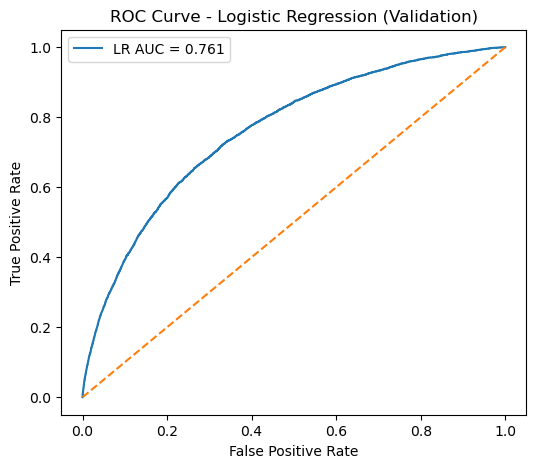

In [47]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_val, proba_val_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"LR AUC = {roc_auc_score(y_val, proba_val_lr):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Validation)")
plt.legend()
plt.show()


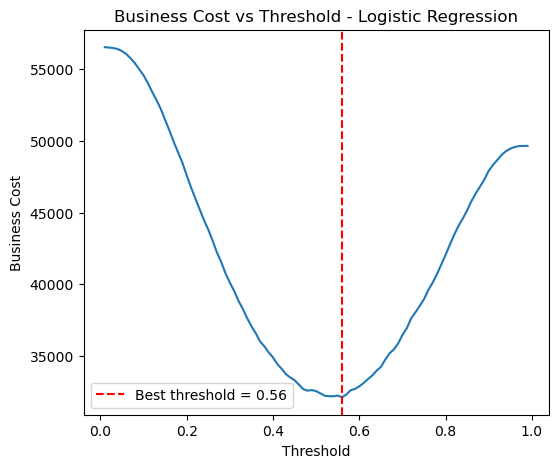

In [48]:
plt.figure(figsize=(6, 5))
plt.plot(thresholds, costs_lr)
plt.axvline(best_t_lr, color="red", linestyle="--", label=f"Best threshold = {best_t_lr:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Business Cost vs Threshold - Logistic Regression")
plt.legend()
plt.show()


### Interprétation des résultats

La régression logistique optimisée obtient une AUC d’environ 0.76.
Après optimisation du seuil métier (FN pondéré 10×), le coût minimal atteint ~32 086 avec un seuil proche de 0.55, constituant une base de référence avant comparaison avec XGBoost.


## Optimisation du modèle : Xgboost

In [49]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipe_xgb_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb_model)
])

pipe_xgb_baseline.fit(X_train, y_train)
proba_val_xgb_baseline = pipe_xgb_baseline.predict_proba(X_val)[:, 1]

print("XGB baseline - ROC AUC (val):", roc_auc_score(y_val, proba_val_xgb_baseline))

XGB baseline - ROC AUC (val): 0.7743780377531824


In [50]:
costs_xgb_baseline = []
cms_xgb_baseline = []

for t in thresholds:
    c, cm = business_cost(y_val, proba_val_xgb_baseline, threshold=t, cost_fn=10, cost_fp=1)
    costs_xgb_baseline.append(c)
    cms_xgb_baseline.append(cm)

best_idx = int(np.argmin(costs_xgb_baseline))
best_t_xgb_baseline = float(thresholds[best_idx])
best_cost_xgb_baseline = float(costs_xgb_baseline[best_idx])
best_cm_xgb_baseline = cms_xgb_baseline[best_idx]

print("XGB baseline - Best threshold:", best_t_xgb_baseline)
print("XGB baseline - Best business cost:", best_cost_xgb_baseline)
print("XGB baseline - Confusion matrix (tn, fp, fn, tp):", best_cm_xgb_baseline)

XGB baseline - Best threshold: 0.09999999999999999
XGB baseline - Best business cost: 30988.0
XGB baseline - Confusion matrix (tn, fp, fn, tp): (np.int64(44180), np.int64(12358), np.int64(1863), np.int64(3102))


In [51]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV


# CV config (TRAIN seulement)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ratio class imbalance pour XGBoost
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Base model (n_estimators sera piloté par Halving)
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=float(ratio),
    tree_method="hist",   # rapide CPU
    n_jobs=1              # IMPORTANT: éviter les conflits de parallélisme
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", xgb)
])

# Espace de recherche (sans n_estimators ici: c'est la "resource")
param_distributions = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.5, 1, 2],
    "model__reg_alpha": [0, 1e-3, 1e-2, 1e-1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = HalvingRandomSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    scoring="roc_auc",
    cv=cv,
    factor=3,                     # élimination agressive
    resource="model__n_estimators",
    min_resources=50,             # démarre léger
    max_resources=400,            # plafonne le temps (augmente si besoin)
    random_state=42,
    verbose=1,
    n_jobs=-1                     # parallélise côté sklearn (folds/candidats)
)

search.fit(X_train, y_train)

print("Best AUC (CV):", search.best_score_)
print("Best params:", search.best_params_)

best_pipe_xgb = search.best_estimator_

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 50
max_resources_: 400
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 8
n_resources: 50
Fitting 3 folds for each of 8 candidates, totalling 24 fits
----------
iter: 1
n_candidates: 3
n_resources: 150
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best AUC (CV): 0.7661727108840729
Best params: {'model__subsample': 0.8, 'model__reg_lambda': 5.0, 'model__reg_alpha': 1.0, 'model__min_child_weight': 10, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__gamma': 2, 'model__colsample_bytree': 0.8, 'model__n_estimators': 150}


In [52]:
proba_val_xgb = best_pipe_xgb.predict_proba(X_val)[:, 1]
print("XGB tuned - AUC validation:", roc_auc_score(y_val, proba_val_xgb))

costs_xgb = []
cms_xgb = []

for t in thresholds:
    c, cm = business_cost(y_val, proba_val_xgb, threshold=t, cost_fn=10, cost_fp=1)
    costs_xgb.append(c)
    cms_xgb.append(cm)

best_idx = int(np.argmin(costs_xgb))
best_t_xgb = float(thresholds[best_idx])
best_cost_xgb = float(costs_xgb[best_idx])
best_cm_xgb = cms_xgb[best_idx]

print("XGB tuned - Best threshold:", best_t_xgb)
print("XGB tuned - Best business cost:", best_cost_xgb)
print("XGB tuned - Confusion matrix (tn, fp, fn, tp):", best_cm_xgb)

XGB tuned - AUC validation: 0.7730754390714127
XGB tuned - Best threshold: 0.51
XGB tuned - Best business cost: 30914.0
XGB tuned - Confusion matrix (tn, fp, fn, tp): (np.int64(42734), np.int64(13804), np.int64(1711), np.int64(3254))


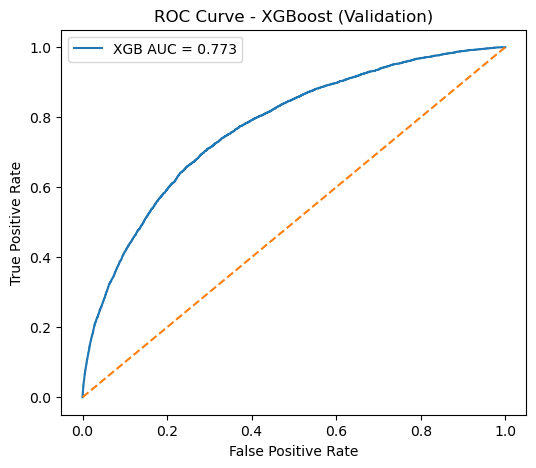

In [53]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, proba_val_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB AUC = {roc_auc_score(y_val, proba_val_xgb):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Validation)")
plt.legend()
plt.show()

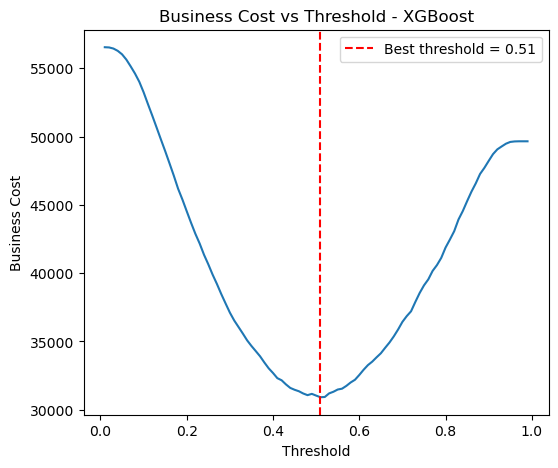

In [54]:
plt.figure(figsize=(6, 5))
plt.plot(thresholds, costs_xgb)
plt.axvline(best_t_xgb, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Business Cost vs Threshold - XGBoost")
plt.legend()
plt.show()

### Interprétation des résultats

La régression logistique optimisée obtient une AUC d’environ 0.77.
Après optimisation du seuil métier (FN pondéré 10×), le coût minimal atteint ~30 914 avec un seuil proche de 0.51. Le coût métier semble donc ici moins élevé que avec la Regression Linéaire

# Comparaison et choix du modèle

In [55]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "AUC_validation": [
        roc_auc_score(y_val, proba_val_lr),
        roc_auc_score(y_val, proba_val_xgb)
    ],
    "Best_threshold": [
        best_t_lr,
        best_t_xgb
    ],
    "Best_business_cost": [
        best_cost_lr,
        best_cost_xgb
    ]
})

comparison.sort_values("Best_business_cost")

,Model,AUC_validation,Best_threshold,Best_business_cost
1,XGBoost,0.773075,0.51,30914.0
0,Logistic Regression,0.761308,0.56,32126.0


Après optimisation et comparaison des résultats pour les deux modèles, on remarque que XGboost est le meilleur. On le garde donc comme modèle. On bascule donc les variables sur celles du modèles final.

In [56]:
# Final model selection

final_model = best_pipe_xgb
final_proba_val = proba_val_xgb
final_threshold = best_t_xgb
final_cost = best_cost_xgb

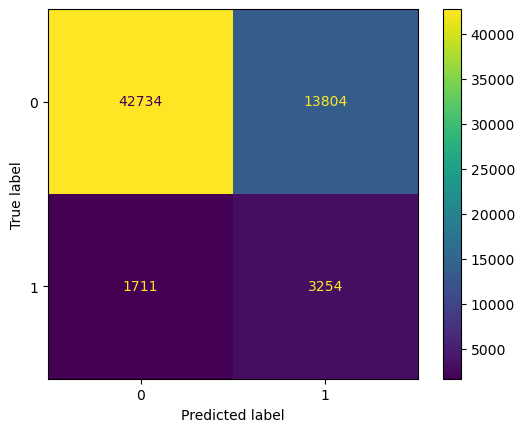

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_final = (final_proba_val >= final_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Le seuil optimal minimise le coût métier en limitant fortement les faux négatifs (défauts non détectés), qui sont les plus coûteux.

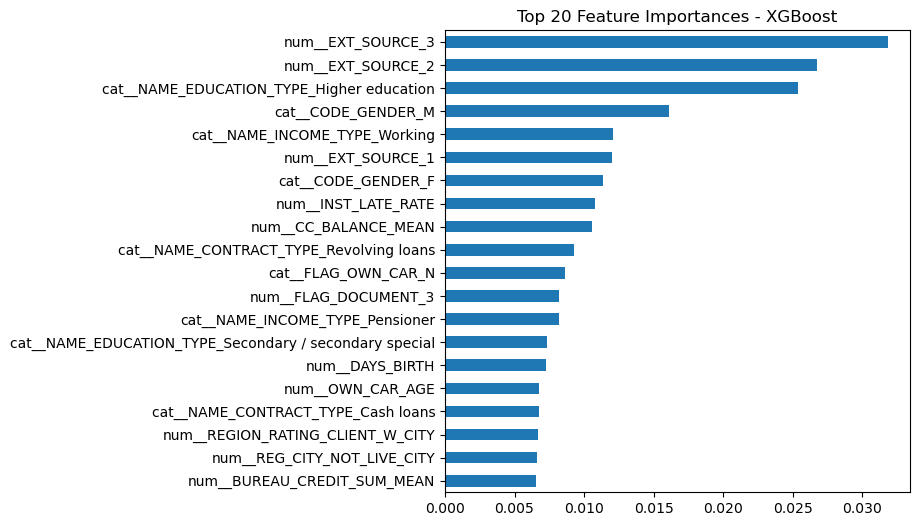

In [58]:
model = final_model.named_steps["model"]

importances = model.feature_importances_

feature_names = final_model.named_steps["preprocess"].get_feature_names_out()

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(6,6))
fi.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()

Les variables les plus importantes sont les scores externes (EXT_SOURCE), ce qui est cohérent avec la littérature en scoring crédit.
Le modèle exploite également l’historique de crédit et certaines caractéristiques socio-économiques.

### Importance gloable des variables



In [59]:
model = final_model.named_steps["model"]
preprocess = final_model.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()
importances = model.feature_importances_

global_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

global_importance.head(20)

,feature,importance
29,num__EXT_SOURCE_3,0.031833
28,num__EXT_SOURCE_2,0.026726
207,cat__NAME_EDUCATION_TYPE_Higher education,0.025408
188,cat__CODE_GENDER_M,0.016075
204,cat__NAME_INCOME_TYPE_Working,0.012059
27,num__EXT_SOURCE_1,0.012016
187,cat__CODE_GENDER_F,0.011359
115,num__INST_LATE_RATE,0.010767
126,num__CC_BALANCE_MEAN,0.010552
186,cat__NAME_CONTRACT_TYPE_Revolving loans,0.009281


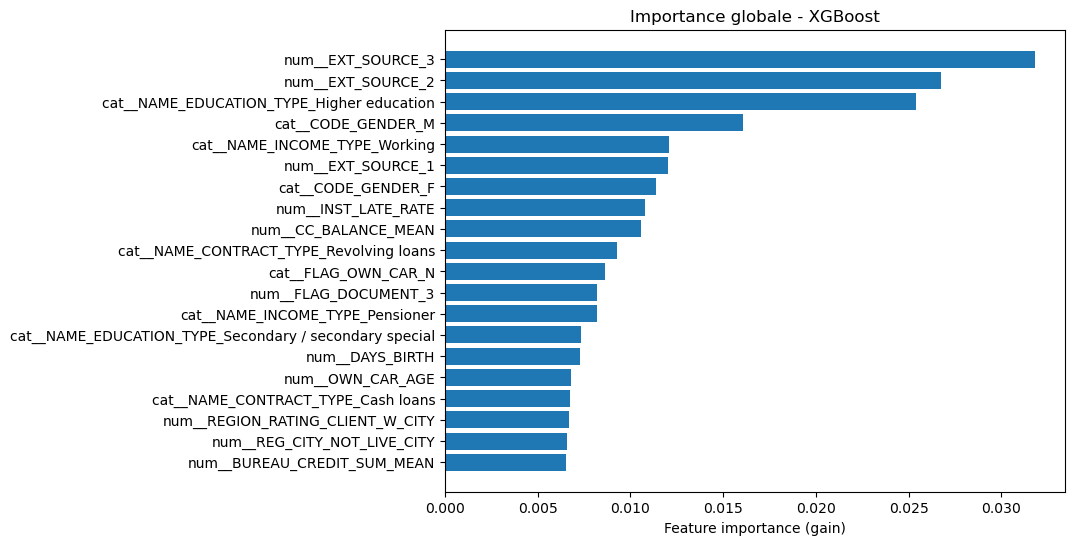

In [60]:
top = global_importance.head(20).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["importance"])
plt.title("Importance globale - XGBoost")
plt.xlabel("Feature importance (gain)")
plt.show()

L’importance globale est analysée à partir du gain fourni par XGBoost.

Dans ce modèle :
- l’importance mesure la contribution moyenne d’une variable à la réduction de l’erreur lors des splits des arbres,
- plus l’importance est élevée, plus la variable est utilisée par le modèle pour améliorer la prédiction,
- contrairement à la régression logistique, cette importance ne donne pas directement le sens de l’effet (augmentation ou diminution du risque).

On observe que :
- les scores externes EXT_SOURCE_3 et EXT_SOURCE_2 sont les variables les plus déterminantes,
- certaines variables socio-économiques comme le niveau d’éducation ou le type de revenu contribuent significativement à la décision,
- des indicateurs liés au comportement de crédit (INST_LATE_RATE, CC_BALANCE_MEAN) jouent également un rôle important.

Ces résultats sont cohérents avec l’intuition métier :
les scores externes captent fortement le risque de défaut, tandis que les variables comportementales et socio-professionnelles affinent la prédiction.

### Importance locale
Ces représentations vont permettre d'identifiant quels éléments ont le plus d'impact sur le modèle à l'échelle d'un seul client, et donc ce qui fait passer un client solvable à un client à risque.

In [61]:
import scipy.sparse as sp

client_id = 0
client = X_val.iloc[[client_id]]

base_proba = final_model.predict_proba(client)[0,1]

preprocess = final_model.named_steps["preprocess"]
model = final_model.named_steps["model"]

X_train_processed = preprocess.transform(X_train)
client_processed = preprocess.transform(client)

if sp.issparse(X_train_processed):
    X_train_processed = X_train_processed.toarray()
if sp.issparse(client_processed):
    client_processed = client_processed.toarray()

reference = np.median(X_train_processed, axis=0)

deltas = []

for j in range(len(feature_names)):
    perturbed = client_processed.copy()
    perturbed[0, j] = reference[j]
    proba_perturbed = model.predict_proba(perturbed)[0,1]
    deltas.append(base_proba - proba_perturbed)

local_importance = pd.DataFrame({
    "feature": feature_names,
    "delta_proba": deltas
})

local_importance["abs_delta"] = np.abs(local_importance["delta_proba"])
local_importance = local_importance.sort_values("abs_delta", ascending=False)

local_importance.head(15)

,feature,delta_proba,abs_delta
4,num__AMT_GOODS_PRICE,-0.157177,0.157177
207,cat__NAME_EDUCATION_TYPE_Higher education,-0.079718,0.079718
29,num__EXT_SOURCE_3,0.040223,0.040223
7,num__DAYS_EMPLOYED,0.034801,0.034801
128,num__CC_LIMIT_MEAN,-0.031286,0.031286
188,cat__CODE_GENDER_M,0.030631,0.030631
108,num__BUREAU_COUNT,0.025207,0.025207
102,num__AMT_REQ_CREDIT_BUREAU_QRT,-0.023093,0.023093
210,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,-0.017777,0.017777
190,cat__FLAG_OWN_CAR_N,-0.016756,0.016756


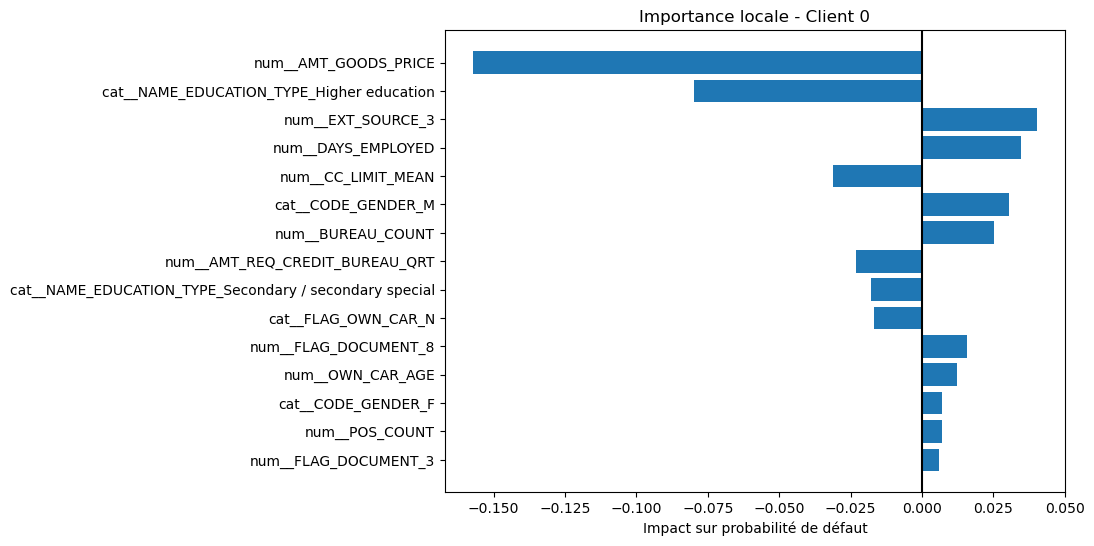

In [62]:
top_local = local_importance.head(15).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(top_local["feature"], top_local["delta_proba"])
plt.axvline(0, color="black")
plt.title(f"Importance locale - Client {client_id}")
plt.xlabel("Impact sur probabilité de défaut")
plt.show()

Le graphique ci-dessus présente les variables ayant le plus contribué à la prédiction du modèle pour ce client spécifique.

Chaque barre représente l’impact d’une variable sur la probabilité prédite de défaut :
- Une contribution positive (à droite) signifie que la variable augmente la probabilité de défaut pour ce client.
- Une contribution négative (à gauche) signifie qu’elle la réduit.
- L’amplitude indique l’intensité de l’influence sur la prédiction.

Pour ce client, on observe notamment que :
- le montant des biens financés (AMT_GOODS_PRICE) réduit fortement la probabilité de défaut,
- le niveau d’éducation supérieur diminue également le risque,
- à l’inverse, certains indicateurs comportementaux comme EXT_SOURCE_3 ou l’ancienneté professionnelle (DAYS_EMPLOYED) augmentent la probabilité prédite.

Cette analyse permet d’expliquer individuellement la décision du modèle et renforce son interprétabilité dans un contexte métier.

## Suivi des expérimentations avec MLflow

Afin d’industrialiser le suivi des modèles et garantir la reproductibilité, nous utilisons MLflow pour tracer :

- les hyperparamètres testés,
- les métriques de performance (AUC, coût métier),
- les versions des modèles entraînés.

Chaque exécution est enregistrée dans l’expérience `credit_scoring` et peut être comparée via l’interface MLflow.


In [63]:
import os
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
   roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

/opt/anaconda3/envs/credit_scoring64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [64]:
print("CWD:", os.getcwd())
print("Tracking URI:", mlflow.get_tracking_uri())

CWD: /Users/emiliemoissette/Desktop/02_Formation AI-Engineer/06_Initiez vous au MLOps/Projet6_MLOps/notebooks
Tracking URI: sqlite:////Users/emiliemoissette/Desktop/02_Formation%20AI-Engineer/06_Initiez%20vous%20au%20MLOps/Projet6_MLOps/notebooks/mlflow.db


In [65]:
import mlflow

mlflow.set_tracking_uri("file:../mlruns")

mlflow.set_experiment("credit_scoring")

print("Tracking URI:", mlflow.get_tracking_uri())



Tracking URI: file:../mlruns


In [66]:
from sklearn.linear_model import LogisticRegression

# --- RUN 1 : baseline
baseline_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ))
])

baseline_pipe.fit(X_train, y_train)

proba_val = baseline_pipe.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= 0.5).astype(int)

auc_base = roc_auc_score(y_val, proba_val)
acc_base = accuracy_score(y_val, pred_val)
prec_base = precision_score(y_val, pred_val, zero_division=0)
rec_base = recall_score(y_val, pred_val, zero_division=0)
f1_base = f1_score(y_val, pred_val, zero_division=0)

with mlflow.start_run(run_name="logreg_baseline"):
    # params
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("threshold", 0.5)

    # metrics
    mlflow.log_metric("auc_validation", float(auc_base))
    mlflow.log_metric("accuracy", float(acc_base))
    mlflow.log_metric("precision", float(prec_base))
    mlflow.log_metric("recall", float(rec_base))
    mlflow.log_metric("f1", float(f1_base))

    # model artifact (version du modèle)
    mlflow.sklearn.log_model(baseline_pipe, artifact_path="model")

print("Baseline AUC:", auc_base)



2026/04/17 11:53:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 11:53:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline AUC: 0.7614125080950644


In [67]:
# --- RUN FINAL : modèle retenu
proba_val_best = final_proba_val
pred_val_best = (proba_val_best >= final_threshold).astype(int)

auc_best = roc_auc_score(y_val, proba_val_best)
acc_best = accuracy_score(y_val, pred_val_best)
prec_best = precision_score(y_val, pred_val_best, zero_division=0)
rec_best = recall_score(y_val, pred_val_best, zero_division=0)
f1_best = f1_score(y_val, pred_val_best, zero_division=0)

with mlflow.start_run(run_name="final_model"):
    # params
    mlflow.log_param("best_threshold", float(final_threshold))

    # metrics
    mlflow.log_metric("auc_validation", float(auc_best))
    mlflow.log_metric("accuracy", float(acc_best))
    mlflow.log_metric("precision", float(prec_best))
    mlflow.log_metric("recall", float(rec_best))
    mlflow.log_metric("f1", float(f1_best))

    # score métier
    mlflow.log_metric("best_business_cost", float(final_cost))

    # model artifact
    mlflow.sklearn.log_model(final_model, artifact_path="model")

print("Final AUC:", auc_best, "| Final threshold:", final_threshold, "| Final cost:", final_cost)

2026/04/17 11:53:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 11:53:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final AUC: 0.7730754390714127 | Final threshold: 0.51 | Final cost: 30914.0


In [68]:
import mlflow

runs = mlflow.search_runs(
    filter_string="attributes.run_name = 'final_model'",
    order_by=["start_time DESC"],
    max_results=1
)

run_id = runs.loc[0, "run_id"]
model_uri = f"runs:/{run_id}/model"

mlflow.register_model(model_uri, "credit_scoring_model")
print("Registered from run:", run_id)

Registered model 'credit_scoring_model' already exists. Creating a new version of this model...
2026/04/17 11:53:17 WARNING mlflow.tracking._model_registry.fluent: Run with id 4d09f4bc3ff04555a70ae9c9b161a539 has no artifacts at artifact path 'model', registering model based on models:/m-ee20f904179b4d94814384b7b6fe60aa instead


Registered from run: 4d09f4bc3ff04555a70ae9c9b161a539


Created version '5' of model 'credit_scoring_model'.


Les expérimentations sont tracées dans MLflow (hyperparamètres, métriques, modèles).  
Deux runs ont été enregistrés dans l’expérience `credit_scoring` :  
- un modèle baseline,  
- un modèle optimisé par validation croisée.  

La comparaison des runs dans l’interface MLflow permet d’analyser :  
- les hyperparamètres testés,  
- l’AUC de validation,  
- le coût métier optimisé.  

Ces éléments sont utilisés pour sélectionner le modèle final.

In [75]:
#On vérifie le bon fonctionnement du modèle 
final_model.predict(X_val.iloc[:5])


array([0, 0, 1, 0, 1])

In [76]:
#On l'associe à pipeline pour la suite 
pipeline = final_model

In [78]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

pipeline = final_model

joblib.dump(pipeline, "../models/credit_scoring_pipeline.joblib")

model = joblib.load("../models/credit_scoring_pipeline.joblib")
model.predict(X_val.iloc[:5])

array([0, 0, 1, 0, 1])